# 7 - Maximum entropy: a population of structures, not a structure

Every notebook before this one has asked "which structure fits my distances?".
That question has an answer even when it should not. A minimiser will always
return one structure, and it will return one whether the molecule really sits
in one place or shuttles between several. If the molecule exchanges, the
single best-fit structure is not the closed state, not the open state, and
usually not any state the molecule visits: it is the structure whose distances
happen to average to what you measured. It looks like a discovery and it is an
artefact of the question.

The honest question is the one this notebook asks:

> Given a set of candidate structures and a set of FRET distances, **what
> population over those structures is consistent with the data?**

That question has too many answers rather than one. Twenty distances that all
report the same motion do not pin down fifty-eight populations, however
favourably you count them against each other; whole families of weightings fit
equally well. Something has to choose among them, and the choice is where the
assumptions hide.

**Maximum entropy** makes the choice explicit: among all populations that fit
the data, take the one closest to a stated prior - the flattest one, if the
prior is flat. Any structure the recovered population *does* pick out is
picked out because the data asked for it, not because the regulariser
preferred it. Maximum entropy will not invent a peak. It will very happily
smear one out, which is exactly the failure mode you have to keep in mind when
you read the result.

IMP.bff carries the solver as `IMP.bff.maxent_invert` (and the raw quadratic
form as `IMP.bff.maxent_solve`). It is the same Skilling-Bryan engine that
sits under `MaxEntSpectrum` for lifetime distributions; nothing in it is
specific to decays, which is why it can take a structural ensemble just as
well.

**The molecule is hGBP1**, the human guanylate-binding protein, and the
ensemble is the recorded conformational transition that ships with this
repository: fifty-eight frames of a coarse-grained trajectory, not an
interpolation between two endpoints. That is the one thing that has really
changed since the earlier version of this notebook, and section 1 measures
what difference it makes - because "we used a real trajectory" is a claim, and
a claim of that kind is worth a number.

**The measurement is still synthetic.** We choose a mixture over the recorded
frames, predict what a labelling network would report for it, add noise, and
invert. That is deliberate - the only way to say whether a method recovers the
truth is to know the truth. Section 1 also brings in the *measured* hGBP1
network that ships alongside the trajectory, but only where it belongs: as a
reality check on the noise level we are entitled to assume. Section 6 says
what happens when the assumption is optimistic.

In [1]:
import pathlib
import sys
import tempfile
import time

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


def _workshop_dir():
    """doc/workshop, found from whatever directory the kernel was started in."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        for rel in ("", "doc/workshop", "workshop"):
            candidate = base / rel if rel else base
            if (candidate / "workshop.py").is_file():
                return candidate
    raise RuntimeError("workshop.py not found next to this notebook")


sys.path.insert(0, str(_workshop_dir()))
import workshop as ws
import IMP.bff as bff

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

T_START = time.time()
SCRATCH = pathlib.Path(tempfile.mkdtemp(prefix="hgbp1_ensemble_"))

RNG_SEED = 5               # the one noise draw the figures are built on
SIGMA_E = 0.01             # uncertainty on a species-averaged transfer efficiency
N_MEMBERS = ws.hgbp1_n_frames()
MEMBER = np.arange(N_MEMBERS)          # the ensemble coordinate: frame number
PROGRESS = MEMBER / (N_MEMBERS - 1)    # the same thing scaled to 0 .. 1

print("IMP.bff", bff.get_module_version(), "| R0 =", ws.R0, "A")
print("recorded transition:", N_MEMBERS, "frames | scratch:", SCRATCH)

IMP.bff ab5de21 | R0 = 52.0 A
recorded transition: 58 frames | scratch: /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/hgbp1_ensemble_80zjzzmv


## 1. The ensemble is recorded, not interpolated

`ws.hgbp1_state(f)` writes frame `f` of the transition as a PDB file. Before
using them, two facts about this topology that you have to respect, because
getting either of them wrong produces distances that look fine and mean
nothing:

* It is a **monomer** of 570 residues. The chain identifiers `A` and `B` in
  the file are *residue ranges*, 1-151 and 152-570, not two protomers. A pair
  written `A18-B344` in this notebook is therefore an intramolecular distance
  across one molecule, and nothing about it is a subunit interface.
* The coordinates are **coarse-grained**. Backbone plus reduced side chains,
  which is enough to occlude a dye and to move a labelling site, and not
  enough to argue about a rotamer.

The cell below writes every frame out and reads the topology back off the
file, rather than restating it.

In [2]:
member_paths = [ws.hgbp1_state(f, cache=SCRATCH) for f in range(N_MEMBERS)]

atom_lines = [line for line in member_paths[0].read_text().splitlines()
              if line.startswith("ATOM")]
chain_range = {}
for line in atom_lines:
    chain, resi = line[21], int(line[22:26])
    low, high = chain_range.get(chain, (resi, resi))
    chain_range[chain] = (min(low, resi), max(high, resi))

print(f"{len(member_paths)} frames written to {SCRATCH}")
print(f"atoms per frame            : {len(atom_lines)}")
print(f"residues                   : {len({int(l[22:26]) for l in atom_lines})}")
for chain, (low, high) in sorted(chain_range.items()):
    print(f'  "chain" {chain}                  : residues {low}-{high}'
          f'  ({sum(1 for l in atom_lines if l[21] == chain)} atoms)')
print(f"C-beta atoms (label sites) : {sum(1 for l in atom_lines if l[12:16].strip() == 'CB')}")

58 frames written to /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/hgbp1_ensemble_80zjzzmv
atoms per frame            : 5235
residues                   : 570
  "chain" A                  : residues 1-151  (1350 atoms)
  "chain" B                  : residues 152-570  (3885 atoms)
C-beta atoms (label sites) : 544


### Is a recorded trajectory richer than a morph between its ends?

The earlier version of this notebook built its ensemble by interpolating
between two deposited structures, and said so as a complaint: a straight line
between two points is a **one-parameter family**, so a "population over the
ensemble" is really a population over a single coordinate, and the inversion
can never discover more than one degree of freedom because there is only one
in the input.

Fifty-eight recorded frames need not be any better. A trajectory can perfectly
well travel in a straight line. So we measure it, with the same construction on
both sides:

1. the pairwise C-alpha RMSD matrix of the 58 recorded frames, and
2. the pairwise C-alpha RMSD matrix of 58 frames of a straight-line morph
   between the *same two endpoints* - frame 0 and frame 57 - which is exactly
   the construction the BmrA version used.

Classical multidimensional scaling turns each matrix into an eigenvalue
spectrum: the fraction of the inter-frame variance that lives along the first
axis, the second, and so on. **A one-parameter family puts everything on the
first axis.** Whatever the recorded frames put anywhere else is structure the
morph did not have.

In [3]:
def ca_coordinates(path):
    return np.array([[float(l[30:38]), float(l[38:46]), float(l[46:54])]
                     for l in pathlib.Path(path).read_text().splitlines()
                     if l.startswith("ATOM") and l[12:16].strip() == "CA"])


def superpose(mobile, target):
    """`mobile` moved onto `target` by the optimal rigid transform."""
    mc, tc = mobile.mean(0), target.mean(0)
    u, _, vt = np.linalg.svd((mobile - mc).T @ (target - tc))
    d = np.sign(np.linalg.det(vt.T @ u.T))
    return (mobile - mc) @ (vt.T @ np.diag([1.0, 1.0, d]) @ u.T).T + tc


def rmsd(a, b):
    a, b = a - a.mean(0), b - b.mean(0)
    values = np.linalg.svd(a.T @ b, compute_uv=False).copy()
    u, _, vt = np.linalg.svd(a.T @ b)
    values[-1] *= np.sign(np.linalg.det(vt.T @ u.T))
    return np.sqrt(max((a * a).sum() + (b * b).sum() - 2.0 * values.sum(), 0.0) / len(a))


def rmsd_matrix(traj):
    n = len(traj)
    out = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            out[i, j] = out[j, i] = rmsd(traj[i], traj[j])
    return out


def mds_spectrum(matrix):
    """Fraction of inter-frame variance on each classical-MDS axis."""
    n = len(matrix)
    centring = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centring @ (matrix ** 2) @ centring
    values, vectors = np.linalg.eigh(gram)
    order = np.argsort(values)[::-1]
    values, vectors = np.clip(values[order], 0.0, None), vectors[:, order]
    return values / values.sum(), vectors * np.sqrt(values)


recorded = np.array([ca_coordinates(p) for p in member_paths])
end_on_start = superpose(recorded[-1], recorded[0])
morph = np.array([(1.0 - t) * recorded[0] + t * end_on_start for t in PROGRESS])

D_recorded, D_morph = rmsd_matrix(recorded), rmsd_matrix(morph)
spec_recorded, embed_recorded = mds_spectrum(D_recorded)
spec_morph, embed_morph = mds_spectrum(D_morph)

far = np.unravel_index(np.argmax(D_recorded), D_recorded.shape)
print(f"C-alpha atoms per frame                 : {recorded.shape[1]}")
print(f"RMSD frame 0 to frame {N_MEMBERS - 1}              : {D_recorded[0, -1]:6.2f} A")
print(f"largest pairwise RMSD in the trajectory : {D_recorded.max():6.2f} A"
      f"  (frames {far[0]} and {far[1]})")
print(f"  -> the two ends are {'NOT ' if D_recorded.max() > D_recorded[0, -1] + 1e-9 else ''}"
      f"the most distant pair of frames")
print()
print(f"{'MDS axis':>9} {'recorded':>10} {'morph':>10}")
for k in range(5):
    print(f"{k + 1:>9} {spec_recorded[k]:10.4f} {spec_morph[k]:10.4f}")
print(f"{'axes for 95%':>9} "
      f"{int(np.searchsorted(np.cumsum(spec_recorded), 0.95) + 1):>10}"
      f" {int(np.searchsorted(np.cumsum(spec_morph), 0.95) + 1):>10}")

C-alpha atoms per frame                 : 570
RMSD frame 0 to frame 57              :  18.88 A
largest pairwise RMSD in the trajectory :  22.49 A  (frames 16 and 45)
  -> the two ends are NOT the most distant pair of frames

 MDS axis   recorded      morph
        1     0.6897     1.0000
        2     0.2379     0.0000
        3     0.0283     0.0000
        4     0.0206     0.0000
        5     0.0130     0.0000
axes for 95%          3          1


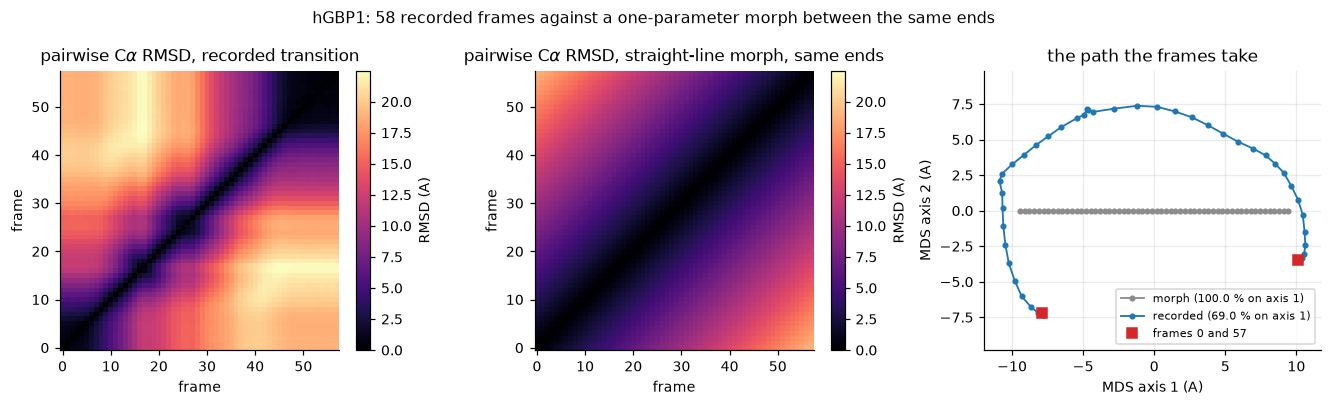

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

vmax = max(D_recorded.max(), D_morph.max())
for ax, matrix, label in ((axes[0], D_recorded, "recorded transition"),
                          (axes[1], D_morph, "straight-line morph, same ends")):
    image = ax.imshow(matrix, origin="lower", cmap="magma", vmin=0.0, vmax=vmax)
    ax.set_xlabel("frame")
    ax.set_ylabel("frame")
    ax.set_title(f"pairwise C$\\alpha$ RMSD, {label}")
    ax.grid(False)
    fig.colorbar(image, ax=ax, fraction=0.046, label="RMSD (A)")

axes[2].plot(embed_morph[:, 0], embed_morph[:, 1], "-o", ms=3, lw=1.2,
             color="0.55", label=f"morph ({100 * spec_morph[0]:.1f} % on axis 1)")
axes[2].plot(embed_recorded[:, 0], embed_recorded[:, 1], "-o", ms=3, lw=1.2,
             color="C0", label=f"recorded ({100 * spec_recorded[0]:.1f} % on axis 1)")
axes[2].plot(embed_recorded[[0, -1], 0], embed_recorded[[0, -1], 1], "s",
             color="C3", ms=7, label="frames 0 and 57")
axes[2].set_xlabel("MDS axis 1 (A)")
axes[2].set_ylabel("MDS axis 2 (A)")
axes[2].set_title("the path the frames take")
axes[2].set_aspect("equal", adjustable="datalim")
axes[2].legend(fontsize=7.5, loc="best")

fig.suptitle("hGBP1: 58 recorded frames against a one-parameter morph between the same ends",
             fontsize=10.5)
fig.tight_layout()
plt.show()

The morph puts 100.0 % of its inter-frame variance on one axis, to the digit -
it is a straight line, and classical MDS says so exactly. The recorded
transition puts about two thirds on the first axis and a quarter on the second,
and needs three axes to reach 95 %. The right-hand panel is the same statement
as a picture: the recorded frames bow away from the chord joining their ends,
and the largest RMSD in the trajectory is between two frames that are *not* the
two ends.

So yes - the frames are richer than the morph they replace, by a factor of
about three in the number of degrees of freedom the ensemble actually has. Two
cautions before that becomes a boast:

* **Richer is not rich.** Three effective degrees of freedom out of 570
  residues is still a very low-dimensional object, and it is low-dimensional
  because a single recorded transition is one path, not a sampled equilibrium.
  An ensemble that is meant to represent a population should come from many
  trajectories or from an enhanced-sampling scheme.
* **Extra degrees of freedom are only useful if the dyes see them.** Section 2
  builds the design matrix, and that is where it is settled whether the second
  and third MDS axes reach the observables at all.

### What the measured network says about the noise we may assume

The repository also carries the **published** hGBP1 FRET network, and unlike
everything else in this notebook those distances were measured. It is worth
loading for one specific purpose.

It is *not* a drop-in for the trajectory. The network is for the hGBP1
**dimer**: its positions come in matched `A`/`B` pairs at the same residue
numbers, which only makes sense for two protomers, and it names residues up to
577, past the end of this 570-residue construct. The trajectory's topology is a
monomer whose chains are residue ranges. Those two things do not map onto each
other, and the cell below checks that rather than asserting it. The dimer the
network belongs to is the one `examples/structure/GBP/hGBP1_dimer.top.dat`
builds with IMP.pmi from 2B8W and friends, which is a different object from the
transition trajectory.

What the network *can* tell us is how big a real error bar on a real hGBP1 FRET
distance is. We assume `sigma = 0.01` on a transfer efficiency below, and the
measured error bars are the way to find out whether that is generous.

In [5]:
network = ws.hgbp1_network()
positions, distances = network["positions"], network["distances"]

values = np.array([d["distance"] for d in distances.values()])
errors = np.array([[d["error_neg"], d["error_pos"]] for d in distances.values()], float)
relative = errors.mean(1) / values
asymmetric = int(np.sum(np.abs(errors[:, 0] - errors[:, 1]) > 1e-9))

print(f"positions                 : {len(positions)}")
print(f"measured distances        : {len(distances)}")
print(f"chi2 sets                 : {network['chi2_sets']}")
print(f"Forster radius            : {sorted({d['Forster_radius'] for d in distances.values()})} A")
print(f"distance convention       : {sorted({d['distance_type'] for d in distances.values()})}")
print(f"distances                 : {values.min():.1f} .. {values.max():.1f} A,"
      f" median {np.median(values):.1f} A")
print(f"error bars                : median {np.median(errors):.2f} A,"
      f" {100 * np.median(relative):.1f} % of the distance;"
      f" {asymmetric} of {len(distances)} are asymmetric")

# Does the network's own addressing resolve against the trajectory topology?
present = {(l[21], int(l[22:26])) for l in atom_lines if l[12:16].strip() == "CB"}
resolves = [name for name, p in positions.items()
            if (p["chain_identifier"], p["residue_seq_number"]) in present]
print(f"\npositions that resolve against the trajectory topology: "
      f"{len(resolves)} of {len(positions)}  {resolves}")
print("  (the network addresses a dimer; the trajectory is a monomer whose"
      " chains are residue ranges)")

# A distance error bar, translated into the efficiency uncertainty it implies.
# E = 1/(1+(R/R0)^6)  ->  dE = 6 E (1-E) dR / R
e_of = 1.0 / (1.0 + (values / 52.0) ** 6)
sigma_e_implied = 6.0 * e_of * (1.0 - e_of) * relative
usable = e_of * (1 - e_of) > 0.01          # pairs that carry information at all
print(f"\nthe same error bars as an uncertainty on E:"
      f" median {np.median(sigma_e_implied[usable]):.3f}"
      f" over the {usable.sum()} pairs in a readable efficiency range")
print(f"this notebook assumes sigma_E = {SIGMA_E} -- optimistic by a factor of"
      f" {np.median(sigma_e_implied[usable]) / SIGMA_E:.0f}. Section 6 pays for that.")

positions                 : 18
measured distances        : 68
chi2 sets                 : ['577_577', 'inter']
Forster radius            : [52] A
distance convention       : ['RDAMean']
distances                 : 28.4 .. 108.3 A, median 67.5 A
error bars                : median 4.29 A, 7.4 % of the distance; 0 of 68 are asymmetric

positions that resolve against the trajectory topology: 7 of 18  ['A18F', 'B254F', 'B344F', 'B481F', 'B496F', 'B525F', 'B540F']
  (the network addresses a dimer; the trajectory is a monomer whose chains are residue ranges)

the same error bars as an uncertainty on E: median 0.046 over the 68 pairs in a readable efficiency range
this notebook assumes sigma_E = 0.01 -- optimistic by a factor of 5. Section 6 pays for that.


### Looking at the transition

The first panel plays the recorded transition: every fourth frame, C-alpha
trace, stepped through in the browser. The second is frame 0 held still and
spinning, with the accessible volumes of one donor and one acceptor site drawn
on it - the clouds, not the C-betas, are what a FRET distance is computed from.

The viewer needs internet access from your browser. If it cannot load, nothing
else in this notebook is affected.

In [6]:
movie_frames = ws.hgbp1_frames(every=4)
donor_view = ws.av(member_paths[0], "A", 18, "Alexa488")
acceptor_view = ws.av(member_paths[0], "B", 496, "Alexa647")
print(f"animation: {len(movie_frames)} of {N_MEMBERS} frames, every 4th")
print(f"<R_DA>_E  A18-B496 at frame  0 : "
      f"{ws.rda_e(donor_view, ws.av(member_paths[0], 'B', 496, 'Alexa647')):.1f} A")
print(f"<R_DA>_E  A18-B496 at frame {N_MEMBERS - 1} : "
      f"{ws.rda_e(ws.av(member_paths[-1], 'A', 18, 'Alexa488'), ws.av(member_paths[-1], 'B', 496, 'Alexa647')):.1f} A")

ws.show([
    {"title": f"hGBP1: the recorded transition, {len(movie_frames)} frames",
     "structure": ws.morph_pdb(movie_frames),
     "animate_models": True, "frame_ms": 300, "clouds": []},
    {"title": "frame 0, with the volumes of A18 (donor) and B496 (acceptor)",
     "structure": ws.protein_for_view(member_paths[0]),
     "spin": True,
     "clouds": [
         {"pdb": ws.av_pdb(donor_view, max_points=900),
          "colour": ws.DONOR_COLOUR, "label": "A18"},
         {"pdb": ws.av_pdb(acceptor_view, max_points=900),
          "colour": ws.ACCEPTOR_COLOUR, "label": "B496"},
     ]},
], height=440)

animation: 15 of 58 frames, every 4th
<R_DA>_E  A18-B496 at frame  0 : 72.4 A
<R_DA>_E  A18-B496 at frame 57 : 58.0 A


## 2. What each member predicts

For every frame we compute an accessible volume at each labelling site and
turn each donor/acceptor pair into `<R_DA>_E` - the distance that reproduces
the mean transfer efficiency of the two clouds, which is what an experiment
reports. The observable we will actually invert is the transfer efficiency
itself,

$$E_k(\text{pair}) = \frac{1}{1 + (\langle R_{DA}\rangle_E / R_0)^6}$$

for member $k$, because efficiency is what a *mixture* averages linearly:

$$E^{\text{obs}}(\text{pair}) = \sum_k w_k \, E_k(\text{pair}).$$

That linearity is the whole reason this problem is a linear inversion and not
a search. Mean distances do **not** average like that - a 60/40 mixture of a
40 A and a 70 A state does not report 52 A - so a network of `<R_DA>_E` values
must be converted to efficiencies before anything is averaged. Getting this
backwards is one of the commoner ways to produce a confident wrong ensemble.

**Sites first, and they have to survive the whole trajectory.** A site whose
accessible volume comes back empty in even one frame cannot be used: the
design matrix would have a hole in it, and a hole is not a small number. The
screen below is over all 58 frames, and it drops sites that a single-structure
screen would have kept - which is a reason to do the site selection on the
ensemble rather than on one model.

In [7]:
CANDIDATES = [18, 30, 60, 86, 100, 118, 135, 151, 165, 177, 195, 210, 225, 240,
              254, 270, 290, 305, 320, 335, 344, 360, 378, 395, 410, 425, 440,
              455, 470, 481, 496, 510, 525, 540, 550, 560, 570]
chain_of = lambda resi: "A" if resi <= chain_range["A"][1] else "B"

start = time.time()
survivors, dropped = [], []
for resi in CANDIDATES:
    empty_in = None
    for f, path in enumerate(member_paths):
        try:
            ws.av(path, chain_of(resi), resi, "Alexa488")
        except ws.EmptyVolume:
            empty_in = f
            break
    if empty_in is None:
        survivors.append(resi)
    else:
        dropped.append((resi, empty_in))
print(f"{len(survivors)} of {len(CANDIDATES)} candidate sites have a volume in"
      f" every frame  ({time.time() - start:.1f} s)")
for resi, frame in dropped:
    print(f"  dropped {chain_of(resi)}{resi}: no accessible volume at frame {frame}"
          f" -- a site that is shut for part of the transition")

# Twenty of the survivors, spread evenly along the sequence rather than taken
# from the front: a network crowded into one half of the molecule reports one
# half of the motion.
picked = sorted(set(np.linspace(0, len(survivors) - 1, 20).round().astype(int)))
SITES = [survivors[i] for i in picked] if len(survivors) > 20 else survivors
print(f"\nusing {len(SITES)} of them, spread along the chain:", SITES)

32 of 37 candidate sites have a volume in every frame  (7.2 s)
  dropped A118: no accessible volume at frame 20 -- a site that is shut for part of the transition
  dropped B165: no accessible volume at frame 0 -- a site that is shut for part of the transition
  dropped B210: no accessible volume at frame 2 -- a site that is shut for part of the transition
  dropped B225: no accessible volume at frame 10 -- a site that is shut for part of the transition
  dropped B305: no accessible volume at frame 44 -- a site that is shut for part of the transition

using 20 of them, spread along the chain: [18, 60, 86, 135, 177, 195, 254, 270, 320, 344, 360, 395, 425, 440, 470, 481, 510, 540, 550, 570]


In [8]:
def design_from(paths, sites):
    """<R_DA>_E for every site pair i<j, and the frames on which it could be built.

    A frame where any site has no accessible volume is left out rather than
    filled in: a hole in a design matrix is not a small number.
    """
    n = len(sites)
    columns, kept = [], []
    for k, path in enumerate(paths):
        try:
            donors = {s: ws.av(path, chain_of(s), s, "Alexa488") for s in sites}
            acceptors = {s: ws.av(path, chain_of(s), s, "Alexa647") for s in sites}
        except ws.EmptyVolume:
            continue
        column = np.zeros((n, n))
        for i, a in enumerate(sites):
            for j, b in enumerate(sites):
                if j > i:
                    column[i, j] = ws.rda_e(donors[a], acceptors[b])
        columns.append(column)
        kept.append(k)
    return np.stack(columns, axis=-1), np.array(kept)


def all_atom_coordinates(path):
    return np.array([[float(l[30:38]), float(l[38:46]), float(l[46:54])]
                     for l in pathlib.Path(path).read_text().splitlines()
                     if l.startswith("ATOM")])


# The control ensemble: the same construction the BmrA version of this notebook
# used, on the same two endpoints -- a straight line in Cartesian space between
# frame 0 and frame 57, written out as 58 members.
first_xyz = all_atom_coordinates(member_paths[0])
last_xyz = superpose(all_atom_coordinates(member_paths[-1]), first_xyz)
morph_paths = []
for f, t in enumerate(PROGRESS):
    coordinates = (1.0 - t) * first_xyz + t * last_xyz
    path = SCRATCH / f"morph_{f:03d}.pdb"
    path.write_text("".join(f"{line[:30]}{x:8.3f}{y:8.3f}{z:8.3f}{line[54:]}\n"
                            for line, (x, y, z) in zip(atom_lines, coordinates)) + "END\n")
    morph_paths.append(path)

start = time.time()
rda_e, kept = design_from(member_paths, SITES)
rda_e_morph, kept_morph = design_from(morph_paths, SITES)
efficiency = 1.0 / (1.0 + (rda_e / ws.R0) ** 6)
efficiency_morph = 1.0 / (1.0 + (rda_e_morph / ws.R0) ** 6)
n_pairs_total = len(SITES) * (len(SITES) - 1) // 2
print(f"{n_pairs_total} candidate pairs x {N_MEMBERS} members, for the recorded"
      f" frames and for the morph, in {time.time() - start:.0f} s"
      f"  ({4 * len(SITES) * N_MEMBERS} accessible volumes)")
print(f"recorded frames usable : {len(kept)} of {N_MEMBERS}")
lost = sorted(set(range(N_MEMBERS)) - set(kept_morph.tolist()))
print(f"morph frames usable    : {len(kept_morph)} of {N_MEMBERS}"
      + (f"  -- lost {lost}" if lost else ""))
if lost:
    print("  a Cartesian interpolation between two structures is not itself a"
          " structure: at those frames it has squeezed a site shut and the dye"
          " has nowhere to go. The morph is used below only as a control, on the"
          " frames where it survives.")

190 candidate pairs x 58 members, for the recorded frames and for the morph, in 68 s  (4640 accessible volumes)
recorded frames usable : 58 of 58
morph frames usable    : 56 of 58  -- lost [52, 53]
  a Cartesian interpolation between two structures is not itself a structure: at those frames it has squeezed a site shut and the dye has nowhere to go. The morph is used below only as a control, on the frames where it survives.


### Choosing a network

A pair is worth measuring only if its efficiency stays in the range an
experiment can read - roughly 0.05 to 0.95, outside which the sixth power
flattens everything - and only if it *changes* across the ensemble. We take
the twenty pairs with the largest span in `E`, allowing each site to appear at
most three times so the network does not collapse onto one loop.

The printed table is worth reading before the fit: the span column is the
ceiling on everything that follows. With a measurement uncertainty of 0.01, a
pair that moves by 0.3 across the whole transition offers about thirty
resolvable steps along the coordinate *if* the pairs were independent - and
whether they are is the question the next figure answers.

In [9]:
def build_network(table, n_pairs=20, e_low=0.06, e_high=0.94, max_uses=3):
    ranked = []
    for i, a in enumerate(SITES):
        for j, b in enumerate(SITES):
            if j <= i:
                continue
            e = table[i, j]
            if e.min() > e_low and e.max() < e_high:
                ranked.append((e.max() - e.min(), a, b, i, j))
    ranked.sort(reverse=True)
    used, network = {}, []
    for span, a, b, i, j in ranked:
        if used.get(a, 0) >= max_uses or used.get(b, 0) >= max_uses:
            continue
        used[a] = used.get(a, 0) + 1
        used[b] = used.get(b, 0) + 1
        network.append((a, b, i, j))
        if len(network) == n_pairs:
            break
    return network


NETWORK = build_network(efficiency)
design = np.array([efficiency[i, j] for _, _, i, j in NETWORK])      # (pairs, members)
design_morph = np.array([efficiency_morph[i, j] for _, _, i, j in NETWORK])
model_distance = np.array([rda_e[i, j] for _, _, i, j in NETWORK])

print(f"{len(NETWORK)} pairs  |  {'pair':>12}  {'R(f=0)':>7} {'R(f=57)':>8}"
      f"   {'E(f=0)':>7} {'E(f=57)':>8} {'span':>6}")
for (a, b, _, _), r, e in zip(NETWORK, model_distance, design):
    print(f"{'':>20}  {f'{chain_of(a)}{a}-{chain_of(b)}{b}':>12}  {r[0]:7.1f} {r[-1]:8.1f}"
          f"   {e[0]:7.2f} {e[-1]:8.2f} {e.max() - e.min():6.2f}")
print(f"\nmedian span in E, recorded frames : {np.median(design.max(1) - design.min(1)):.3f}")
print(f"median span in E, the same pairs on the morph : "
      f"{np.median(design_morph.max(1) - design_morph.min(1)):.3f}"
      f"   (over its {design_morph.shape[1]} usable frames)")

20 pairs  |          pair   R(f=0)  R(f=57)    E(f=0)  E(f=57)   span
                         B177-B570     41.4     65.1      0.80     0.21   0.86
                         B510-B570     78.3     73.6      0.08     0.11   0.76
                         B195-B540     39.9     63.3      0.83     0.24   0.74
                          A18-B550     57.7     36.3      0.35     0.90   0.70
                          A60-B550     62.5     40.8      0.25     0.81   0.68
                         B254-B510     60.9     45.8      0.28     0.68   0.67
                         B254-B570     55.2     64.8      0.41     0.21   0.66
                          A86-B395     63.5     57.7      0.23     0.35   0.63
                          A18-B344     45.8     41.6      0.68     0.79   0.62
                         B177-B550     55.4     59.9      0.41     0.30   0.60
                          A86-B440     56.7     50.9      0.37     0.53   0.60
                          A60-B510     66.0     45.9      0.1

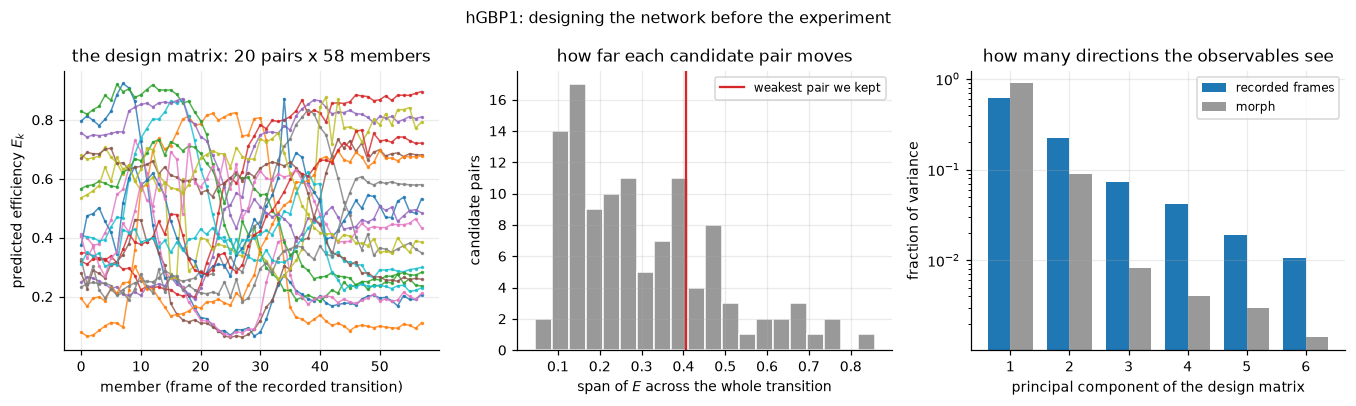

candidate pairs in a readable efficiency range : 113
of those, pairs whose E moves by less than 0.05: 2

variance on the first design component, recorded 0.6164 | morph 0.8897
components for 99 % of the variance, recorded 8 | morph 4


In [10]:
def variance_spectrum(matrix):
    centred = matrix - matrix.mean(1, keepdims=True)
    singular = np.linalg.svd(centred, compute_uv=False) ** 2
    return singular / singular.sum()


spectrum, spectrum_morph = variance_spectrum(design), variance_spectrum(design_morph)

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

for row, (a, b, _, _) in zip(design, NETWORK):
    axes[0].plot(MEMBER, row, marker=".", ms=2.5, lw=1, alpha=0.8)
axes[0].set_xlabel("member (frame of the recorded transition)")
axes[0].set_ylabel("predicted efficiency $E_k$")
axes[0].set_title(f"the design matrix: {len(NETWORK)} pairs x {N_MEMBERS} members")

blind = []
for i in range(len(SITES)):
    for j in range(i + 1, len(SITES)):
        e = efficiency[i, j]
        if e.min() > 0.06 and e.max() < 0.94:
            blind.append(e.max() - e.min())
axes[1].hist(blind, bins=20, color="0.6", edgecolor="white")
axes[1].axvline((design.max(1) - design.min(1)).min(), color="C3", lw=1.5,
                label="weakest pair we kept")
axes[1].set_xlabel("span of $E$ across the whole transition")
axes[1].set_ylabel("candidate pairs")
axes[1].set_title("how far each candidate pair moves")
axes[1].legend(fontsize=8)

index = np.arange(1, 7)
axes[2].bar(index - 0.19, spectrum[:6], 0.38, color="C0", label="recorded frames")
axes[2].bar(index + 0.19, spectrum_morph[:6], 0.38, color="0.6", label="morph")
axes[2].set_yscale("log")
axes[2].set_xlabel("principal component of the design matrix")
axes[2].set_ylabel("fraction of variance")
axes[2].set_title("how many directions the observables see")
axes[2].legend(fontsize=8)

fig.suptitle("hGBP1: designing the network before the experiment", fontsize=10.5)
fig.tight_layout()
plt.show()

print(f"candidate pairs in a readable efficiency range : {len(blind)}")
print(f"of those, pairs whose E moves by less than 0.05: {sum(1 for s in blind if s < 0.05)}")
print(f"\nvariance on the first design component, recorded {spectrum[0]:.4f}"
      f" | morph {spectrum_morph[0]:.4f}")
print(f"components for 99 % of the variance, recorded "
      f"{int(np.searchsorted(np.cumsum(spectrum), 0.99) + 1)}"
      f" | morph {int(np.searchsorted(np.cumsum(spectrum_morph), 0.99) + 1)}")

Three things to read off that figure.

**The left panel does not look like the BmrA version of this notebook**, and
that is the point. There the design curves were near-straight and
near-parallel; here they wander, cross one another and change direction partway
through the transition. Near-parallel columns make a near-singular design
matrix, in which a mixture of two members predicts almost exactly what the
member halfway between them predicts, and no amount of solver sophistication
separates the two. Crossing, curving columns are what buys resolution, and a
recorded path produces them where a straight line cannot.

**The middle panel** says this network is not short of sensitive pairs: with a
transition this large, almost every candidate pair in a readable efficiency
range moves by many times the noise. That is a property of hGBP1's transition,
not a general fact, and section 6 comes back to what it is worth.

**The right panel** needs a caveat. Even the morph's design matrix has more
than one principal component, because $E$ is a sixth-power function of a
distance and no two pairs curve alike, so a one-parameter family of
*structures* still traces a curved track in efficiency space. The component
count is therefore not a clean measure of how many degrees of freedom the
ensemble has - the structural MDS spectrum of section 1 is, and that one was
unambiguous. What this spectrum does measure is how much of the ensemble's
richness survives the journey to the observables, and the recorded frames keep
more of it: 62 % of their variance on the first component against the morph's
89 %, and eight components to reach 99 % against the morph's four.

## 3. A synthetic measurement

Now we invent the answer so that we can check the method against it.

The truth is a **two-state mixture**: 60 % of the molecules in an early frame
of the transition and 40 % in a late one. That is the physically interesting
case and the one a single-structure fit gets wrong - the average of those two
states is not either of them.

The measurement is `E` for each of the twenty pairs, plus Gaussian noise with
`sigma = 0.01`. Section 1 already established what that number is worth: the
measured hGBP1 network's error bars imply an efficiency uncertainty about five
times larger. So read sections 4 and 5 as the best case, and section 6 for what
the realistic error bar costs - which on this ensemble turns out to be less
than you would expect.

Everything from here on uses only `measured`, `SIGMA_E` and `design`. The true
weights are put aside and only brought back to score the answer.

In [11]:
MAJOR, MINOR = 12, 41          # two frames of the recorded transition
w_true = np.zeros(N_MEMBERS)
w_true[MAJOR] = 0.60
w_true[MINOR] = 0.40

rng = np.random.default_rng(RNG_SEED)
noiseless = design @ w_true
measured = noiseless + rng.normal(0.0, SIGMA_E, len(NETWORK))

print(f"true mixture: 60 % frame {MAJOR} + 40 % frame {MINOR}"
      f"  (C-alpha RMSD between them {D_recorded[MAJOR, MINOR]:.1f} A)")
print(f"\n{'pair':>12} {'E(frame 0)':>11} {'E(frame 57)':>12} {'E(mixture)':>11} {'E(measured)':>12}")
for (a, b, _, _), e, truth, obs in zip(NETWORK, design, noiseless, measured):
    print(f"{f'{chain_of(a)}{a}-{chain_of(b)}{b}':>12} {e[0]:11.3f} {e[-1]:12.3f}"
          f" {truth:11.3f} {obs:12.3f}")

chi2_truth = float(((noiseless - measured) ** 2).sum()) / SIGMA_E ** 2 / len(NETWORK)
print(f"\nchi2 per pair at the true weights: {chi2_truth:.2f}  (should scatter around 1)")

true mixture: 60 % frame 12 + 40 % frame 41  (C-alpha RMSD between them 21.5 A)

        pair  E(frame 0)  E(frame 57)  E(mixture)  E(measured)
   B177-B570       0.796        0.206       0.337        0.329
   B510-B570       0.079        0.111       0.464        0.451
   B195-B540       0.830        0.236       0.632        0.630
    A18-B550       0.349        0.896       0.456        0.460
    A60-B550       0.248        0.810       0.479        0.490
   B254-B510       0.280        0.681       0.488        0.490
   B254-B570       0.413        0.211       0.376        0.371
    A86-B395       0.233        0.349       0.450        0.442
    A18-B344       0.681        0.793       0.714        0.721
   B177-B550       0.406        0.299       0.640        0.657
    A86-B440       0.374        0.532       0.529        0.532
    A60-B510       0.194        0.678       0.406        0.394
   B254-B360       0.567        0.282       0.542        0.533
    A86-B540       0.320        0.722

## 4. The inversion

`IMP.bff.maxent_invert` minimises

$$Q(x) \;=\; \sum_i w_i \,(Ax - b)_i^2 \;-\; \nu^2 S(x;\,m), \qquad x \ge 0,$$

with $S$ the Skilling-Bryan entropy relative to the prior $m$, which peaks
where $x = m$. So the first term is the fit and the second pulls the answer
towards the prior; `nu` sets the exchange rate between them, and note that it
enters **squared** - doubling `nu` quadruples the pull.

The pieces map onto our problem directly:

| argument | here |
|---|---|
| `design` | the (pairs x members) matrix of predicted efficiencies, row-major |
| `measurements` | the measured efficiencies |
| `weights` | `1/sigma^2` per row |
| `prior` | flat, `1/N` per member - "no member is favoured" |
| `nu` | the regularisation weight |
| `n_rows`, `n_cols` | the shape, passed explicitly because the matrix arrives flat |

One thing the solver does not know is that weights are a population and must
sum to one. It only enforces `x >= 0`. We add the constraint as an extra row
of ones with measurement 1 and a very small uncertainty, which is the usual
trick: a constraint is a measurement you are very sure of. Making that
uncertainty far *too* small is a real way to break the solve - the row then
dominates the normal equations and the iteration stalls - so we use 1e-3,
tight compared to `SIGMA_E` and not absurd.

`MaxEntSolution` carries more than the amplitudes: `chisq` (the weighted sum
of squares, including our constraint row), `entropy`, `objective`,
`iterations`, `gradient_angle`, and two flags that are easy to confuse.
`success` only says the routine ran; a solve that exhausted `max_iter` is
still a success. `converged` is the actual stopping test, `gradient_angle <=
tol`. At small `nu` the entropy gradient is tiny and that angle test can fail
to trigger at all - you will see `converged = False` with the full iteration
count below, and the amplitudes are still perfectly usable. Report both, and
never read `success` as "it worked".

In [12]:
help(bff.maxent_invert)

Help on function maxent_invert in module IMP.bff:

maxent_invert(design, measurements, weights, prior, nu, n_rows, n_cols, max_iter=500, tol=1e-08)
    maxent_invert(DistBase design, DistBase measurements, DistBase weights, DistBase prior, double nu, int n_rows, int n_cols, int max_iter=500, double tol=1e-8) -> MaxEntSolution



In [13]:
def maxent_weights(design, measured, sigma, nu, prior=None,
                   sum_to_one_sigma=1e-3, max_iter=20000, tol=1e-8):
    """Populations over the ensemble members, by maximum entropy.

    Returns the amplitudes, the chi-square per measured pair, the entropy and
    the raw MaxEntSolution so the convergence flags stay visible.
    """
    n_rows, n_members = design.shape
    sigma = np.broadcast_to(np.asarray(sigma, float), (n_rows,))
    a = np.vstack([design, np.ones(n_members)])                  # + the normalisation row
    b = np.append(np.asarray(measured, float), 1.0)
    weights = np.append(1.0 / sigma ** 2, 1.0 / sum_to_one_sigma ** 2)
    prior = np.full(n_members, 1.0 / n_members) if prior is None else np.asarray(prior, float)

    solution = bff.maxent_invert(a.ravel().tolist(), b.tolist(), weights.tolist(),
                                 prior.tolist(), float(nu), a.shape[0], a.shape[1],
                                 int(max_iter), float(tol))
    x = np.asarray(solution.get_amplitudes())
    residual = design @ x - measured
    chi2 = float(residual @ (residual / sigma ** 2)) / n_rows
    entropy = float(np.sum((1.0 - np.log(np.maximum(x, 1e-300) / prior)) * x) - prior.sum())
    return x, chi2, entropy, solution


NU = 0.5
w_maxent, chi2_maxent, entropy_maxent, solution = maxent_weights(design, measured, SIGMA_E, NU)

print(f"nu                 : {NU}")
print(f"sum of weights     : {w_maxent.sum():.4f}")
print(f"chi2 per pair      : {chi2_maxent:.3f}   (true weights give {chi2_truth:.2f})")
print(f"entropy            : {entropy_maxent:.3f}")
print(f"iterations         : {solution.iterations}")
print(f"success / converged: {solution.success} / {solution.converged}  "
      f"(gradient angle {solution.gradient_angle:.2e})")
print(f"\nflat population would be {1 / N_MEMBERS:.4f} on every member;"
      f" the twelve largest weights:")
print(f"{'member':>7} {'true':>7} {'maxent':>8}")
for k in np.argsort(w_maxent)[::-1][:12]:
    print(f"{k:7d} {w_true[k]:7.2f} {w_maxent[k]:8.3f}  {'#' * int(round(40 * w_maxent[k]))}")
print(f"\n<member>  true {w_true @ MEMBER:.2f} | maxent {w_maxent @ MEMBER / w_maxent.sum():.2f}")

nu                 : 0.5
sum of weights     : 1.0001
chi2 per pair      : 0.733   (true weights give 0.91)
entropy            : -2.990
iterations         : 20000
success / converged: True / False  (gradient angle 3.32e-01)

flat population would be 0.0172 on every member; the twelve largest weights:
 member    true   maxent
     12    0.60    0.528  #####################
     41    0.40    0.371  ###############
     14    0.00    0.052  ##
     43    0.00    0.025  #
     11    0.00    0.011  
      8    0.00    0.006  
     53    0.00    0.005  
     40    0.00    0.002  
     19    0.00    0.000  
     20    0.00    0.000  
     21    0.00    0.000  
     17    0.00    0.000  

<member>  true 23.60 | maxent 23.88


### Reading the answer

This is a better answer than the interpolated ensemble of the earlier version
of this notebook gave, and it is worth being precise about what "better" means.

The two members that really carry population are the two the solve puts weight
on, and they are the top two by a wide margin. Their heights are systematically
too low - about 0.53 and 0.37 against a true 0.60 and 0.40 - and the missing
tenth has gone to their immediate neighbours. That is maximum entropy doing
exactly what it advertises: among the populations that fit, it takes the
flattest, and a peak spread over two adjacent frames of a trajectory fits as
well as a peak on one. **Read the position of a maximum-entropy peak as the
determined quantity and its height as a lower bound.**

Two summaries of the same numbers, over repeated noise draws:

* The **first moment** - the mean position along the coordinate,
  $\langle k\rangle = \sum_k w_k\,k$ - and the **coarse split** between early
  and late members both come back essentially exactly.
* The **individual member weights** are stable in position and biased low in
  height, and that bias does not shrink with better data. It is the
  regulariser, not the noise.

The vertical bars in the figure are not error bars from the fit. Each one is
the range the weight on that member takes over fifty independent noise draws
on the *same* true mixture: it is what "run the experiment again" does to the
recovered population. A peak that fits comfortably inside its own bar is noise
wearing the costume of a conformational state. If a paper shows you a
maximum-entropy population without these bars, you cannot tell which of its
peaks are real - and neither can its authors. Here the bars are narrow and
both peaks stand well clear of them.

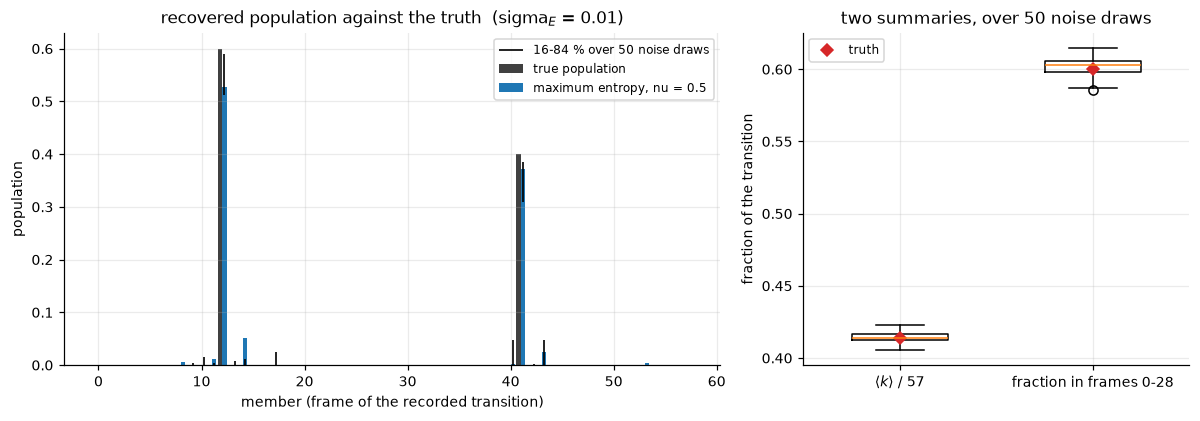

<member>         true 23.60 | recovered 23.58 [23.41, 23.83]
fraction early   true  0.60 | recovered  0.60 [0.60, 0.61]
weight on the true major state (frame 12), over draws: 0.55 +/- 0.04 (true 0.60)
weight on the true minor state (frame 41), over draws: 0.35 +/- 0.04 (true 0.40)
the member carrying the largest weight, over draws: 1 different members out of 58


In [14]:
REPEATS = 50
repeat_weights = np.array([
    maxent_weights(design,
                   design @ w_true + np.random.default_rng(500 + k).normal(0.0, SIGMA_E, len(NETWORK)),
                   SIGMA_E, NU)[0]
    for k in range(REPEATS)])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.9),
                         gridspec_kw={"width_ratios": [1.7, 1]})
axes[0].bar(MEMBER - 0.22, w_true, 0.44, color="0.25", label="true population")
axes[0].bar(MEMBER + 0.22, w_maxent, 0.44, color="C0", label=f"maximum entropy, nu = {NU}")
axes[0].vlines(MEMBER + 0.22, np.percentile(repeat_weights, 16, axis=0),
               np.percentile(repeat_weights, 84, axis=0), color="k", lw=1.1,
               label=f"16-84 % over {REPEATS} noise draws")
axes[0].set_xlabel("member (frame of the recorded transition)")
axes[0].set_ylabel("population")
axes[0].set_title(f"recovered population against the truth  (sigma$_E$ = {SIGMA_E})")
axes[0].legend(fontsize=8)

mean_member = repeat_weights @ MEMBER / repeat_weights.sum(1)
early = MEMBER <= (N_MEMBERS - 1) / 2
early_fraction = repeat_weights[:, early].sum(1) / repeat_weights.sum(1)
axes[1].boxplot([mean_member / (N_MEMBERS - 1), early_fraction],
                tick_labels=[r"$\langle k \rangle$ / 57", "fraction in frames 0-28"],
                widths=0.5)
axes[1].plot([1, 2], [w_true @ MEMBER / (N_MEMBERS - 1), w_true[early].sum()], "D",
             color="C3", ms=6, label="truth")
axes[1].set_ylabel("fraction of the transition")
axes[1].set_title(f"two summaries, over {REPEATS} noise draws")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"<member>         true {w_true @ MEMBER:5.2f} | recovered "
      f"{np.percentile(mean_member, 50):5.2f} "
      f"[{np.percentile(mean_member, 16):.2f}, {np.percentile(mean_member, 84):.2f}]")
print(f"fraction early   true {w_true[early].sum():5.2f} | recovered "
      f"{np.percentile(early_fraction, 50):5.2f} "
      f"[{np.percentile(early_fraction, 16):.2f}, {np.percentile(early_fraction, 84):.2f}]")
print(f"weight on the true major state (frame {MAJOR}), over draws: "
      f"{repeat_weights[:, MAJOR].mean():.2f} +/- {repeat_weights[:, MAJOR].std():.2f} (true 0.60)")
print(f"weight on the true minor state (frame {MINOR}), over draws: "
      f"{repeat_weights[:, MINOR].mean():.2f} +/- {repeat_weights[:, MINOR].std():.2f} (true 0.40)")
print(f"the member carrying the largest weight, over draws: "
      f"{len(set(repeat_weights.argmax(1)))} different members out of {N_MEMBERS}")

### The same inversion, run on the morph

Section 1 measured the difference between the recorded frames and a
straight-line morph as a property of the *structures*. Here is the same
difference as a property of the *answer*: build the identical mixture on the
morph control, give it the identical noise, and invert it with the same solver
and the same `nu`. Both ensembles have the same number of members, span the
same two endpoints and are read by the same twenty pairs, so the only thing
that differs between the two rows below is the path taken between the ends.

In [15]:
# The control run: the identical mixture, noise and solver on the morph.
morph_position = {frame: k for k, frame in enumerate(kept_morph)}
w_true_morph = np.zeros(design_morph.shape[1])
w_true_morph[morph_position[MAJOR]] = 0.60
w_true_morph[morph_position[MINOR]] = 0.40
morph_member = kept_morph.astype(float)

DRAWS = 25
print(f"{'ensemble':>21} {'w(major)':>9} {'w(minor)':>9} {'elsewhere':>10}"
      f" {'<member>':>18}")
for label, matrix, truth, coordinate in (
        ("recorded frames", design, w_true, MEMBER.astype(float)),
        ("straight-line morph", design_morph, w_true_morph, morph_member)):
    recovered = np.array([
        maxent_weights(matrix,
                       matrix @ truth + np.random.default_rng(900 + k).normal(0.0, SIGMA_E, matrix.shape[0]),
                       SIGMA_E, NU)[0]
        for k in range(DRAWS)])
    on_true = recovered[:, truth > 0]
    elsewhere = recovered.sum(1) - on_true.sum(1)
    centre = recovered @ coordinate / recovered.sum(1)
    print(f"{label:>21} {on_true[:, 0].mean():9.3f} {on_true[:, 1].mean():9.3f}"
          f" {elsewhere.mean():10.3f}"
          f" {centre.mean():10.2f} +/-{centre.std():5.2f}")
print(f"\ntrue values: w(major) 0.60, w(minor) 0.40, elsewhere 0.00,"
      f" <member> {w_true @ MEMBER:.2f}   ({DRAWS} noise draws each, sigma_E = {SIGMA_E})")
print("'elsewhere' is the population the solver put on members that carry none -"
      " the price of an ensemble whose neighbouring members predict nearly the"
      " same efficiencies.")

             ensemble  w(major)  w(minor)  elsewhere           <member>


      recorded frames     0.552     0.337      0.111      23.60 +/- 0.19


  straight-line morph     0.293     0.058      0.649      23.69 +/- 0.38

true values: w(major) 0.60, w(minor) 0.40, elsewhere 0.00, <member> 23.60   (25 noise draws each, sigma_E = 0.01)
'elsewhere' is the population the solver put on members that carry none - the price of an ensemble whose neighbouring members predict nearly the same efficiencies.


Those two rows are the whole argument of section 1, restated as an outcome.

Both inversions find the mean position of the population: as a ruler for "how
far along the transition is the sample on average", the morph is perfectly
serviceable. But the morph scatters about two thirds of the population onto
members that carry none of it, and loses the minor state almost entirely, while
the recorded frames keep both peaks standing at roughly nine tenths of their
true height. An ensemble whose members are near-interchangeable cannot report a
population over them, however good the data - and interchangeable is exactly
what equally spaced points on a straight line are.

## 5. What `nu` does

`nu` buys smoothness with fit quality, and the exchange rate is not linear.
Sweep it and three regimes appear:

* **`nu` too small.** The entropy term is negligible, the solve is a
  non-negative least squares, and the answer is a few spikes wherever the
  noise happened to point. `chi2` stops improving - the data are already
  fitted - but the spikes keep moving from one noise draw to the next. This is
  the regime in which people publish structures that do not exist.
* **`nu` too large.** The answer is the prior. `chi2` climbs and the
  population is flat: you have measured nothing but you cannot be wrong.
* **In between** there is a corner, and the L-curve - `chi2` against entropy -
  is the usual way to find it. Above the corner you pay a lot of fit for a
  little smoothness; below it, a lot of structure for no improvement in fit.

The historic maximum-entropy recipe is stricter: pick the `nu` at which the
reduced chi-square equals 1, on the grounds that fitting better than the noise
is fitting the noise. `MaxEntSpectrum` implements exactly that as its
`target_chisq` setting, searching over `nu` for you.

On the interpolated BmrA ensemble that recipe failed outright: the smallest
reachable chi-square was already below 1 and chi-square only climbed back to 1
once `nu` was large enough to flatten the population, so the criterion handed
you the prior.

Here it does not fail. The smallest reachable chi-square is still below 1 -
twenty pairs do not over-determine fifty-eight weights - but chi-square crosses
1 at a `nu` where the population is still clearly peaked on the right member,
smoothed rather than erased. The criterion and the L-curve corner still
disagree, and neither is automatic; on this problem they bracket a sensible
answer instead of pointing in opposite directions. Read the gap between them as
the size of the choice you are making, and report the `nu` you used either
way.

In [16]:
nu_grid = np.geomspace(0.01, 100.0, 24)
sweep = [maxent_weights(design, measured, SIGMA_E, nu) for nu in nu_grid]
sweep_w = np.array([s[0] for s in sweep])
sweep_chi2 = np.array([s[1] for s in sweep])
sweep_entropy = np.array([s[2] for s in sweep])

nu_chi2_one = (float(np.interp(1.0, sweep_chi2, nu_grid))
               if sweep_chi2[0] < 1.0 < sweep_chi2[-1] else np.nan)
print(f"{'nu':>8} {'chi2/pair':>10} {'entropy':>9} {'<k>':>7} {'max w':>7}  converged  iterations")
for nu, (w, chi2, entropy, sol) in zip(nu_grid, sweep):
    print(f"{nu:8.3g} {chi2:10.3f} {entropy:9.4f} {w @ MEMBER / w.sum():7.2f} {w.max():7.3f}"
          f"{str(sol.converged):>11}  {sol.iterations}")
if np.isfinite(nu_chi2_one):
    w_at_one, _, _, _ = maxent_weights(design, measured, SIGMA_E, nu_chi2_one)
    print(f"\nnu at chi2 per pair = 1 : {nu_chi2_one:.1f}")
    print(f"  largest weight there  : {w_at_one.max():.3f} on member {int(np.argmax(w_at_one))}"
          f"   (flat would be {1 / N_MEMBERS:.3f}; nu = {NU} gives {w_maxent.max():.3f})")
    print(f"  <member> there        : {w_at_one @ MEMBER / w_at_one.sum():.2f}"
          f"   (true {w_true @ MEMBER:.2f})")
else:
    print("\nchi2 per pair never crosses 1 on this grid: the smallest achievable "
          "chi2 is already above 1, so the criterion has no solution at all")

      nu  chi2/pair   entropy     <k>   max w  converged  iterations
    0.01      0.732   -3.0489   23.90   0.536      False  20000
  0.0149      0.732   -3.0489   23.90   0.536      False  20000
  0.0223      0.732   -3.0489   23.90   0.536      False  20000
  0.0332      0.732   -3.0488   23.90   0.536      False  20000
  0.0496      0.732   -3.0486   23.90   0.536      False  20000
  0.0741      0.732   -3.0481   23.90   0.536      False  20000
   0.111      0.732   -3.0471   23.90   0.536      False  20000
   0.165      0.732   -3.0448   23.89   0.536      False  20000
   0.246      0.732   -3.0356   23.89   0.534      False  20000
   0.367      0.732   -3.0148   23.89   0.532      False  20000
   0.548      0.733   -2.9810   23.87   0.526      False  20000
   0.819      0.734   -2.9328   23.86   0.517      False  20000
    1.22      0.737   -2.8719   23.85   0.503      False  20000
    1.82      0.747   -2.7813   23.86   0.483      False  20000
    2.72      0.792   -2.6112   23.

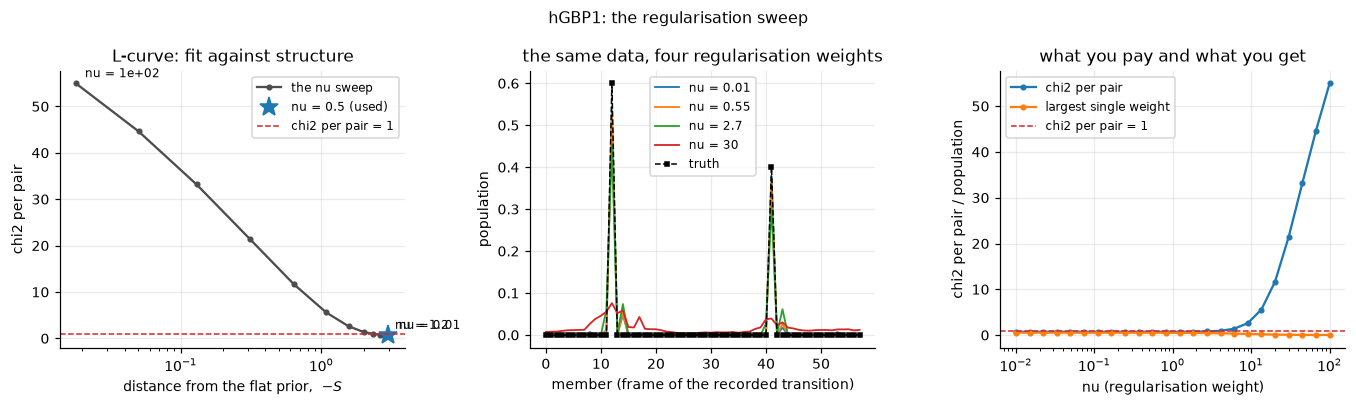

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

axes[0].plot(-sweep_entropy, sweep_chi2, "-o", ms=3, color="0.3", label="the nu sweep")
for nu, s, c in zip(nu_grid, -sweep_entropy, sweep_chi2):
    if nu in (nu_grid[0], nu_grid[len(nu_grid) // 2], nu_grid[-1]):
        axes[0].annotate(f"nu = {nu:.2g}", (s, c), textcoords="offset points",
                         xytext=(6, 4), fontsize=8)
axes[0].plot(-entropy_maxent, chi2_maxent, "*", ms=13, color="C0", label=f"nu = {NU} (used)")
axes[0].axhline(1.0, color="C3", lw=1, ls="--", label="chi2 per pair = 1")
axes[0].set_xlabel("distance from the flat prior,  $-S$")
axes[0].set_ylabel("chi2 per pair")
axes[0].set_xscale("log")
axes[0].set_title("L-curve: fit against structure")
axes[0].legend(fontsize=8)

for nu in (0.01, 0.5, 3.0, 30.0):
    k = int(np.argmin(np.abs(nu_grid - nu)))
    axes[1].plot(MEMBER, sweep_w[k], lw=1.2, label=f"nu = {nu_grid[k]:.2g}")
axes[1].plot(MEMBER, w_true, "k--", lw=1, marker="s", ms=3, label="truth")
axes[1].set_xlabel("member (frame of the recorded transition)")
axes[1].set_ylabel("population")
axes[1].set_title("the same data, four regularisation weights")
axes[1].legend(fontsize=8)

axes[2].semilogx(nu_grid, sweep_chi2, "-o", ms=3, color="C0", label="chi2 per pair")
axes[2].semilogx(nu_grid, sweep_w.max(1), "-o", ms=3, color="C1", label="largest single weight")
axes[2].axhline(1.0, color="C3", lw=1, ls="--", label="chi2 per pair = 1")
axes[2].set_xlabel("nu (regularisation weight)")
axes[2].set_ylabel("chi2 per pair / population")
axes[2].set_title("what you pay and what you get")
axes[2].legend(fontsize=8)

fig.suptitle("hGBP1: the regularisation sweep", fontsize=10.5)
fig.tight_layout()
plt.show()

## 6. What this data set can and cannot say

The BmrA version of this notebook ended here with a list of failures. On this
ensemble most of them do not happen, and saying so is more useful than
repeating them. Five questions, five answers from the run below.

**Can the data tell a mixture from a single structure?** Emphatically. The best
single frame - and it is not one of the two the sample visits - fits worse than
the mixture by a factor in the hundreds, and the printout checks whether it is
still rejected once the error bar is raised to what the measured network
implies.

**Can the data locate the two states?** Yes, and all but uniquely: of the 3364
two-member mixtures scored, only two come within 0.25 of the best chi-square,
and they are the true pair listed both ways round. This is the question the
interpolated BmrA ensemble could not answer, and the reason it can be answered
here is section 1 - adjacent members of a recorded path are distinguishable in
a way that adjacent points on a straight line are not.

**Which structural differences are invisible?** On this transition, very few.
We build a second network out of the twenty *weakest* pairs that are still in a
readable efficiency range and run the identical analysis, expecting it to fail.
It does not: it finds the right member too, because this transition is large
enough that even the least sensitive measurable pair moves by several times the
noise. What the weak network loses is precision - its mean position scatters
roughly ten times as widely from one noise draw to the next. So the lesson
survives in a weaker form. The span of the design matrix does not decide
whether you get an answer on a molecule like this; it decides how sharp the
answer is. It is still the thing to compute before a single photon is
collected.

**What happens at the noise level the measured network implies?** Section 1 put
that at about five times the `sigma` used above. The last panel runs the same
inversion across a range of `sigma` that includes it and goes well past it, and
the two peaks stay where they are throughout. What they lose is height: the
table under the figure puts them at 0.55 and 0.35 at `sigma` 0.01, at 0.33 and
0.17 at the measured network's 0.05 - with half the population smeared onto
neighbouring members by then - and at about a tenth each by `sigma` 0.2. So the
position of the population is robust here and its height is not, which is the
same lesson as the paragraph above rather than a new one. It is a better
outcome than the BmrA version had, and it is a property of the transition being
large rather than of the method being better.

**So what does this ensemble not resolve?** Two things, and they are the two
worth quoting. It does not resolve *which* of two or three adjacent frames
carries the population; the leakage in the tables is precisely that ambiguity.
And it does not give an unbiased peak height, because the regulariser smears by
construction. Both are statements about the granularity of the ensemble, not
about the quality of the data.

In [18]:
SIGMA_REAL = round(float(np.median(sigma_e_implied[usable])), 2)

# (a) the best single structure
single_chi2 = np.array([((design[:, k] - measured) ** 2).sum() / SIGMA_E ** 2 / len(NETWORK)
                        for k in range(N_MEMBERS)])
best_single = int(np.argmin(single_chi2))
print(f"best single member         : frame {best_single}, chi2 per pair {single_chi2[best_single]:.2f}")
print(f"true two-state mixture     : chi2 per pair {chi2_truth:.2f}")
print(f"maximum-entropy population : chi2 per pair {chi2_maxent:.2f}")
print(f"  -> the single structure is worse by a factor "
      f"{single_chi2[best_single] / chi2_maxent:.1f};"
      f" it sits {min(abs(best_single - MAJOR), abs(best_single - MINOR))} frames from"
      f" the nearer true state and the sample never visits it")
single_real = single_chi2[best_single] * (SIGMA_E / SIGMA_REAL) ** 2
mixture_real = chi2_truth * (SIGMA_E / SIGMA_REAL) ** 2
print(f"at sigma = {SIGMA_REAL}, the error bar the measured network implies, the"
      f" same comparison is single {single_real:.2f} vs mixture {mixture_real:.2f}")
print(f"  -> a single structure is"
      f" {'still rejected' if single_real > 1.0 else 'no longer rejected'} there")

# (b) every two-member mixture, optimally weighted
two_state = np.zeros((N_MEMBERS, N_MEMBERS))
for i in range(N_MEMBERS):
    for j in range(N_MEMBERS):
        diff = design[:, i] - design[:, j]
        f = (np.clip(((measured - design[:, j]) @ diff) / (diff @ diff), 0.0, 1.0)
             if diff @ diff > 0 else 0.0)
        model = f * design[:, i] + (1.0 - f) * design[:, j]
        two_state[i, j] = ((model - measured) ** 2).sum() / SIGMA_E ** 2 / len(NETWORK)
acceptable = np.argwhere(two_state <= two_state.min() + 0.25)
print(f"\ntwo-member mixtures within 0.25 of the best chi2: {len(acceptable)}"
      f" of {N_MEMBERS ** 2}")
print(f"  their members span frames {acceptable.min()} .. {acceptable.max()}"
      f"  (truth: {MAJOR} and {MINOR})")

# (c) the twenty least sensitive pairs that are still measurable
weak = sorted((efficiency[i, j].max() - efficiency[i, j].min(), i, j)
              for i in range(len(SITES)) for j in range(i + 1, len(SITES))
              if efficiency[i, j].min() > 0.06 and efficiency[i, j].max() < 0.94)[:20]
blind_design = np.array([efficiency[i, j] for _, i, j in weak])
spans = blind_design.max(1) - blind_design.min(1)
print(f"\nblind network              : {len(blind_design)} pairs, spans in E "
      f"{spans.min():.3f} .. {spans.max():.3f}  (the noise is {SIGMA_E})")
blind_measured = (blind_design @ w_true
                  + np.random.default_rng(99).normal(0.0, SIGMA_E, len(blind_design)))
w_blind, chi2_blind, _, _ = maxent_weights(blind_design, blind_measured, SIGMA_E, NU)
print(f"  its answer               : chi2 per pair {chi2_blind:.2f}, largest weight "
      f"{w_blind.max():.3f} at frame {int(np.argmax(w_blind))} "
      f"(a flat population would be {1 / N_MEMBERS:.3f} everywhere)")


def mean_member_spread(matrix, sigma, draws=30):
    values = []
    for k in range(draws):
        noise = np.random.default_rng(700 + k).normal(0.0, sigma, matrix.shape[0])
        w, *_ = maxent_weights(matrix, matrix @ w_true + noise, sigma, NU)
        values.append(w @ MEMBER / w.sum())
    return np.percentile(values, [16, 50, 84])


print(f"\n<member> over 30 noise draws            (true {w_true @ MEMBER:.2f})")
for label, matrix in (("informative network", design), ("blind network      ", blind_design)):
    low, mid, high = mean_member_spread(matrix, SIGMA_E)
    print(f"  {label}: {mid:5.2f}  [{low:5.2f}, {high:5.2f}]")

best single member         : frame 14, chi2 per pair 249.10
true two-state mixture     : chi2 per pair 0.91
maximum-entropy population : chi2 per pair 0.73
  -> the single structure is worse by a factor 340.0; it sits 2 frames from the nearer true state and the sample never visits it
at sigma = 0.05, the error bar the measured network implies, the same comparison is single 9.96 vs mixture 0.04
  -> a single structure is still rejected there

two-member mixtures within 0.25 of the best chi2: 2 of 3364
  their members span frames 12 .. 41  (truth: 12 and 41)

blind network              : 20 pairs, spans in E 0.044 .. 0.128  (the noise is 0.01)


  its answer               : chi2 per pair 0.30, largest weight 0.467 at frame 12 (a flat population would be 0.017 everywhere)

<member> over 30 noise draws            (true 23.60)


  informative network: 23.67  [23.41, 23.87]


  blind network      : 24.28  [21.16, 26.14]


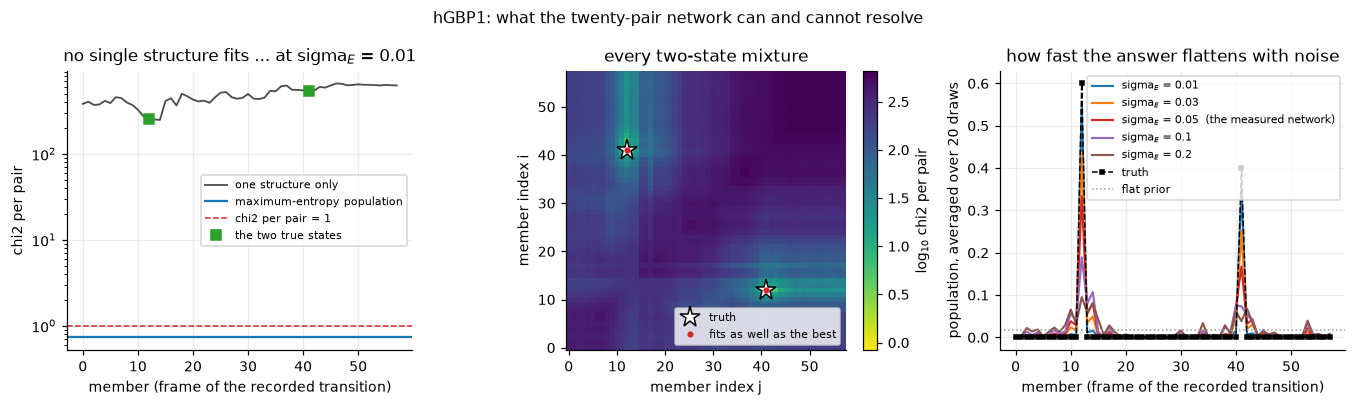

  sigma_E  w(major)  w(minor)  elsewhere  sd <member>
    0.010     0.546     0.351      0.103         0.31
    0.030     0.437     0.252      0.311         0.93
    0.050     0.334     0.168      0.499         1.54
    0.100     0.189     0.073      0.737         2.99
    0.200     0.095     0.039      0.866         5.02
true values: 0.600 0.400 0.000   -- averaged over 20 noise draws at each sigma


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.7))

axes[0].plot(MEMBER, single_chi2, "-", lw=1.2, color="0.3", label="one structure only")
axes[0].axhline(chi2_maxent, color="C0", lw=1.5, label="maximum-entropy population")
axes[0].axhline(1.0, color="C3", lw=1, ls="--", label="chi2 per pair = 1")
axes[0].plot(MEMBER[w_true > 0], single_chi2[w_true > 0], "s", color="C2", ms=7,
             label="the two true states")
axes[0].set_yscale("log")
axes[0].set_xlabel("member (frame of the recorded transition)")
axes[0].set_ylabel("chi2 per pair")
axes[0].set_title(f"no single structure fits ... at sigma$_E$ = {SIGMA_E}")
axes[0].legend(fontsize=7)

image = axes[1].imshow(np.log10(two_state), origin="lower", cmap="viridis_r")
axes[1].plot([MINOR, MAJOR], [MAJOR, MINOR], "*", color="white", ms=14, mec="k",
             label="truth")
axes[1].plot(acceptable[:, 1], acceptable[:, 0], ".", color="C3", ms=6,
             label="fits as well as the best")
axes[1].set_xlabel("member index j")
axes[1].set_ylabel("member index i")
axes[1].set_title("every two-state mixture")
axes[1].grid(False)
axes[1].legend(fontsize=7, loc="lower right")
fig.colorbar(image, ax=axes[1], fraction=0.046, label="log$_{10}$ chi2 per pair")

SIGMAS = (SIGMA_E, 0.03, SIGMA_REAL, 0.10, 0.20)
noise_table = []
for sigma, colour in zip(SIGMAS, ("C0", "C1", "C3", "C4", "C5")):
    draws = np.array([
        maxent_weights(design,
                       design @ w_true + np.random.default_rng(700 + k).normal(0.0, sigma, len(NETWORK)),
                       sigma, NU)[0]
        for k in range(20)])
    average = draws.mean(0)
    noise_table.append((sigma, average[MAJOR], average[MINOR],
                        average.sum() - average[MAJOR] - average[MINOR],
                        (draws @ MEMBER / draws.sum(1)).std()))
    label = f"sigma$_E$ = {sigma}" + ("  (the measured network)" if sigma == SIGMA_REAL else "")
    axes[2].plot(MEMBER, average, lw=1.4, color=colour, label=label)
axes[2].plot(MEMBER, w_true, "k--", marker="s", ms=3, lw=1, label="truth")
axes[2].axhline(1 / N_MEMBERS, color="0.6", lw=1, ls=":", label="flat prior")
axes[2].set_xlabel("member (frame of the recorded transition)")
axes[2].set_ylabel("population, averaged over 20 draws")
axes[2].set_title("how fast the answer flattens with noise")
axes[2].legend(fontsize=7)

fig.suptitle("hGBP1: what the twenty-pair network can and cannot resolve", fontsize=10.5)
fig.tight_layout()
plt.show()

print(f"{'sigma_E':>9} {'w(major)':>9} {'w(minor)':>9} {'elsewhere':>10} {'sd <member>':>12}")
for sigma, major, minor, elsewhere, spread in noise_table:
    print(f"{sigma:9.3f} {major:9.3f} {minor:9.3f} {elsewhere:10.3f} {spread:12.2f}")
print(f"true values: {0.60:.3f} {0.40:.3f} {0.0:.3f}"
      f"   -- averaged over 20 noise draws at each sigma")

## 7. What to take away

1. **Fit a population, not a structure.** The moment a molecule exchanges, the
   single best-fit structure is a weighted average of things that exist, and
   it need not exist itself. Here the best single frame is one the sample never
   visits.
2. **A recorded ensemble is worth more than an interpolated one, and it is
   measurable how much.** Section 1 measured it in the structures: the 58 frames
   need three MDS axes to account for 95 % of their inter-frame variance, where a
   straight-line morph between the same two endpoints needs exactly one, and the
   most distant pair of frames in the trajectory is not its two ends. Section 4
   measured it in the answer: on the morph, two thirds of the recovered
   population lands on members that carry none and the minor state is all but
   lost, while on the recorded frames both peaks stand. That is the difference
   between an ensemble and a ruler.
3. **Compute the design matrix before the experiment.** Structural richness is
   only useful if the observables see it. Here they do - the design columns
   cross and curve where the morph's ran parallel - but that has to be checked,
   and it can be checked before any data exist.
4. **Maximum entropy is a stated assumption, not the absence of one.** It says
   "closest to the prior among everything that fits". Change the prior and you
   change the answer; the prior is a scientific claim and belongs in the
   methods section next to `nu`.
5. **Report `nu` and how you chose it.** The L-curve corner and the
   `chi2 = 1` criterion do not agree, and neither is automatic. On this problem
   they at least bracket the same answer, which they did not on the interpolated
   ensemble.
6. **Read peak position, not peak height.** The solve returned about 0.53 and
   0.37 for a true 0.60 and 0.40, and the missing population went to the
   immediately neighbouring frames. That bias is the regulariser, not the noise,
   and more data does not remove it.
7. **The two peaks survive a realistic error bar** - about five times the
   `sigma` the best case assumes - at roughly half their true height. That is
   not a general result. It follows from this transition being nearly 19 A of
   C-alpha RMSD, so the best pairs move by more than half an efficiency unit
   across it. A smaller motion buys none of it, which is why the design matrix,
   and not the solver, is where a study of this kind is won or lost.

Caveats specific to this notebook, so they are not mistaken for results:

* the trajectory is a single coarse-grained transition path, not a sampled
  equilibrium ensemble, so the populations we invert for are populations over
  one path;
* the measurement is synthetic - the real hGBP1 network in the repository
  belongs to the dimer and does not address this topology, as section 1
  verified, so it was used only to calibrate the noise;
* the accessible volumes are AV1 with generic linker geometry rather than the
  calibrated geometry of that `fps.json`;
* it is a single Gaussian-noise draw rather than simulated bursts, and there is
  no uncertainty in the forward model at all, whereas in practice the position
  of a dye cloud is worth a few Angstrom on its own and would broaden every
  conclusion above.

In [20]:
import shutil

shutil.rmtree(SCRATCH, ignore_errors=True)
print("scratch ensemble removed:", SCRATCH)
print(f"total notebook runtime: {time.time() - T_START:.0f} s")

scratch ensemble removed: /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/hgbp1_ensemble_80zjzzmv
total notebook runtime: 275 s
